In [1]:
## Importing dataset and packages
## Keeping only necessary columns and making species numeric
import pandas as pd
import sys
import os 
df = pd.read_csv("penguins.csv")
df = df.drop(columns=["island", "year", "sex"])
df = df.dropna(axis = 0)
df.species= pd.Categorical(df.species).codes
unique_values = pd.unique(df['species']).tolist()
print(unique_values)

[0, 2, 1]


In [2]:
## Importing necessary packages
import proxUtil 
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler

In [3]:
## Importing necessary packages
## Sorting to fix class rewrite error
## Splitting test and training data
## Normalizing test and training datasets
from sklearn.model_selection import train_test_split
sc = StandardScaler()
penguin_TRAIN, penguin_TEST = train_test_split(df, test_size= 0.5)
penguin_TRAIN = penguin_TRAIN.sort_values(by = "species")
penguin_TEST = penguin_TEST.sort_values(by = "species")
penguin_TRAIN.iloc[:,1:] = sc.fit_transform(penguin_TRAIN.iloc[:,1:])
penguin_TEST.iloc[:,1:] = sc.transform(penguin_TEST.iloc[:,1:])
X_Train = penguin_TRAIN.iloc[:,1:]
Y_Train = penguin_TRAIN.iloc[:,0]

In [4]:
## Importing necessary packages
## Fitting KNN model and making KNN predictions
## Print KNN accuracy score
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score
knn_model = KNeighborsClassifier()
knn_model.fit(penguin_TRAIN.drop(columns= "species"), penguin_TRAIN.species)
pred = knn_model.predict(penguin_TEST.drop(columns= "species"))
true = penguin_TEST.species
print(f"KNN Accuracy Score: {accuracy_score(true, pred)}")
is_correct = pred == true

KNN Accuracy Score: 0.9824561403508771


In [242]:
## Commenting out function needed to time KNN model
# def time_knn():
#     knn_model = KNeighborsClassifier()
#     knn_model.fit(penguin_TRAIN.drop(columns= "species"), penguin_TRAIN.species)
#     pred = knn_model.predict(penguin_TEST.drop(columns= "species"))

In [243]:
## Commenting out call to KNN timing function
# import timeit
# timeit.timeit(time_knn, number = 1000)

In [5]:
## Turning train and test data into tsv files, removing headers
penguin_TRAIN.to_csv("penguin_TRAIN.tsv", sep = "\t", index= False, header = False)
penguin_TEST.to_csv("penguin_TEST.tsv", sep = "\t", index= False, header = False)

In [6]:
## Call to PF-GAP model and predictions
# NOT FOR GENERATING ACCURACIES
proxUtil.getProx("penguin_TRAIN.tsv", "penguin_TRAIN.tsv", modelname="Spartacus", distances=['euclidean'])

In [7]:
f0 = open("Predictions.txt")
f1 = f0.read()
preds = eval("np.array(" + f1 + ")")
f0.close()

In [8]:
#proxUtil.evalPF("penguin_TEST.tsv", modelname="Spartacus")
proxUtil.evalPF("penguin_TRAIN.tsv", modelname="Spartacus")

In [9]:
## Printing PF-GAP Accuracy Score
f0 = open("Predictions_saved.txt")
f1 = f0.read()
preds_saved = eval("np.array(" + f1 + ")")
f0.close()
print(f"PF-GAP Accuracy Score: {accuracy_score(true, preds)}")
#is_correct_PF = true == preds

PF-GAP Accuracy Score: 0.8888888888888888


In [249]:
len(preds)

171

In [250]:
np.unique([preds[i]-preds_saved[i] for i in range(len(preds))])

array([0])

In [251]:
p,y=proxUtil.getProxArrays()

In [252]:
p = proxUtil.SymmetrizeProx(p)

In [253]:
outlier_scores = proxUtil.getOutlierScores(p,y)

In [254]:
embed = MDS(n_components=2, random_state=0, dissimilarity='precomputed')
mds = MDS(n_components=2, random_state=0)
x_trans_test = mds.fit_transform(penguin_TEST)
dis = (np.ones(p.shape) - p)**4
x_trans = embed.fit_transform(dis)
xt = x_trans.transpose()
sizes = [x*100 for x in outlier_scores]

In [255]:
is_correct_train = Y_Train == preds
sum(Y_Train == preds)

171

In [256]:
colorlab = Y_Train
# Define the mapping
label_map = {
    0: "Adelie",
    1: "Chinstrap",
    2: "Gentoo"
}
named_labels = colorlab.map(label_map)

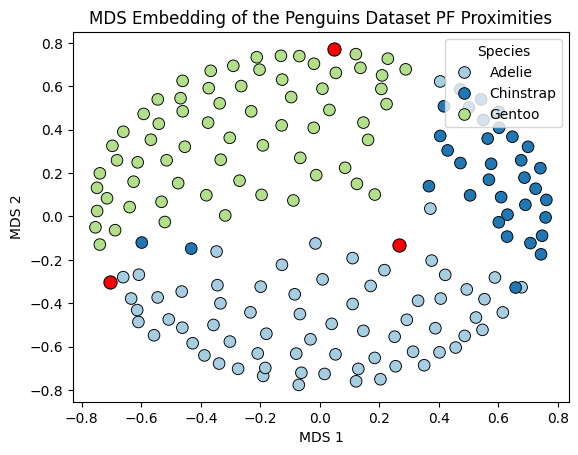

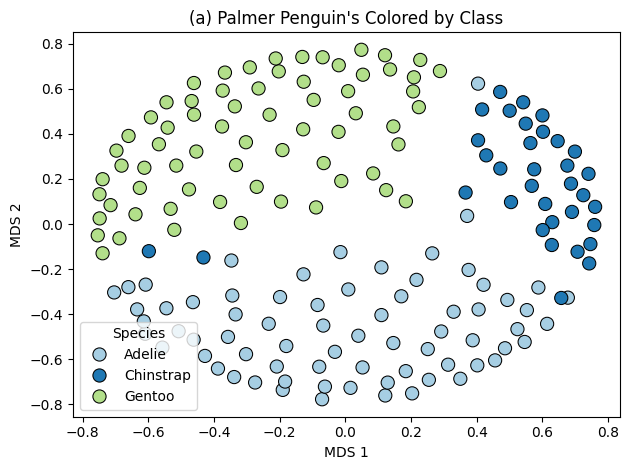

In [ ]:
## Creating plot for PF-GAP outliers
#Species name for legend
import seaborn as sns


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Build DataFrame
df_plot = pd.DataFrame({
    'x': xt[0],
    'y': xt[1],
    'species': colorlab.map(label_map),
    'outlier': np.array(outlier_scores) > 3
})

# Step 2: Plot normal points (species-colored)
sns.scatterplot(
    data=df_plot[df_plot['outlier'] == False],
    x='x',
    y='y',
    hue='species',
    palette='Paired',
    edgecolor='black',
    s=70
)

# Step 3: Overlay outliers (red, same shape)
sns.scatterplot(
    data=df_plot[df_plot['outlier'] == True],
    x='x',
    y='y',
    color='red',         # fixed color for all outliers
    marker='o',          # same shape (circle)
    s=90,                # slightly larger
    edgecolor='black',
    legend=False         # don't add to legend
)

# Step 4: Labels
plt.title("MDS Embedding of the Penguins Dataset PF Proximities")
plt.xlabel("MDS 1")
plt.ylabel("MDS 2")
plt.legend(title='Species')


## Shows penguin class guessed correctly with outliers (for the whole system) in red
handles, labels = plt.gca().get_legend_handles_labels()
filtered = [(h, l) for h, l in zip(handles, labels) if l != "True"]
if filtered:
    handles, labels = zip(*filtered)
    plt.legend(handles=handles, labels=labels, title="Species")
plt.savefig("outlierplot.pdf")
plt.show()


## Shows true class of the penguins guessed correctly 
sns.scatterplot(x = xt[0], y = xt[1], palette= "Paired", hue=colorlab.map(label_map), style = is_correct_train, s=90, edgecolor = "black")
plt.title("(a) Palmer Penguin's Colored by Class")
plt.xlabel("MDS 1")
plt.ylabel("MDS 2")
plt.legend(title='Species')
handles, labels = plt.gca().get_legend_handles_labels()
filtered = [(h, l) for h, l in zip(handles, labels) if l != "True"]
if filtered:
    handles, labels = zip(*filtered)
    plt.legend(handles=handles, labels=labels, title="Species")
plt.tight_layout()
plt.savefig("classplot.pdf")
plt.show()

C:\Users\sofia\AppData\Local\Temp\ipykernel_53132\3578129418.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_plot['outlier'] = df_plot.groupby('species', group_keys=False).apply(compute_outliers)


outlier
False    160
True      11
Name: count, dtype: int64


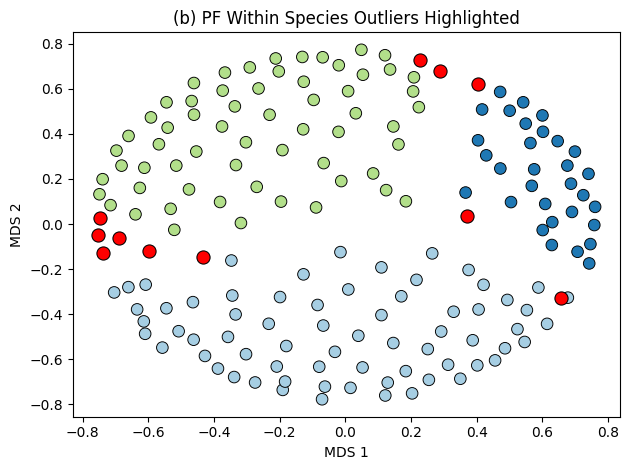

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Step 1: Create the DataFrame
df_plot = pd.DataFrame({
    'x': xt[0],
    'y': xt[1],
    'species': colorlab.map(label_map)
})

# Step 2: Compute outliers per species
def compute_outliers(group, threshold=2):
    z_x = zscore(group['x'])
    z_y = zscore(group['y'])
    combined_z = np.sqrt(z_x**2 + z_y**2)
    return pd.Series(combined_z > threshold, index=group.index)

df_plot['outlier'] = df_plot.groupby('species', group_keys=False).apply(compute_outliers)

# Optional: Debug
print(df_plot['outlier'].value_counts())

# Step 3: Plot inliers
sns.scatterplot(
    data=df_plot[df_plot['outlier'] == False],
    x='x',
    y='y',
    hue='species',
    palette='Paired',
    edgecolor='black',
    s=70
)

# Step 4: Plot outliers
sns.scatterplot(
    data=df_plot[df_plot['outlier'] == True],
    x='x',
    y='y',
    color='red',
    marker='o',
    s=90,
    edgecolor='black',
    legend=False
)


## Shows correctly guessed class with interspecies outliers in red
plt.legend().remove()
plt.title("(b) PF Within Species Outliers Highlighted")
plt.xlabel("MDS 1")
plt.ylabel("MDS 2")
plt.tight_layout()
plt.savefig("classoutlier.pdf")
plt.show()


In [259]:
X1 = np.array([x_trans[i] for i in range(x_trans.shape[0]) if y[i]==0]).transpose()
X2 = np.array([x_trans[i] for i in range(x_trans.shape[0]) if y[i]==1]).transpose()
eX = [X1,X2]

outs1 = np.array([sizes[i] for i in range(x_trans.shape[0]) if y[i]==0]).transpose()
outs2 = np.array([sizes[i] for i in range(x_trans.shape[0]) if y[i]==1]).transpose()
Outs = [outs1,outs2]

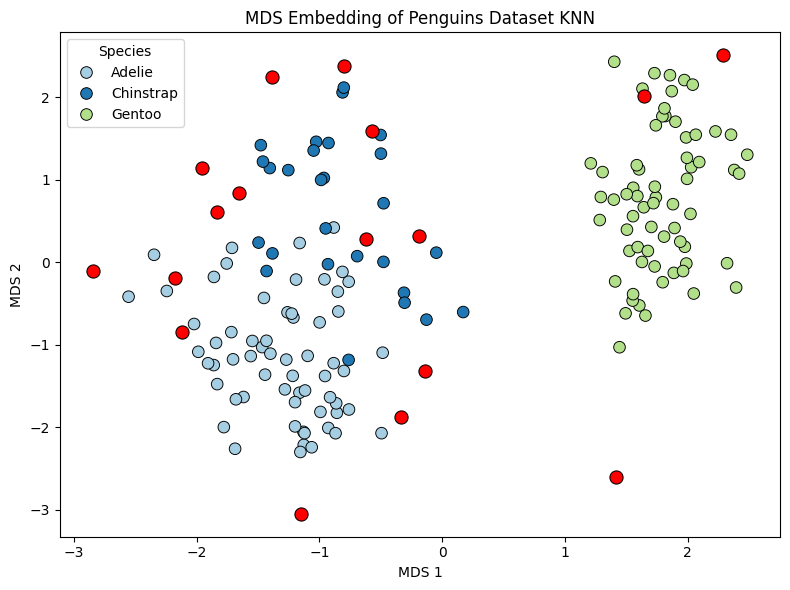

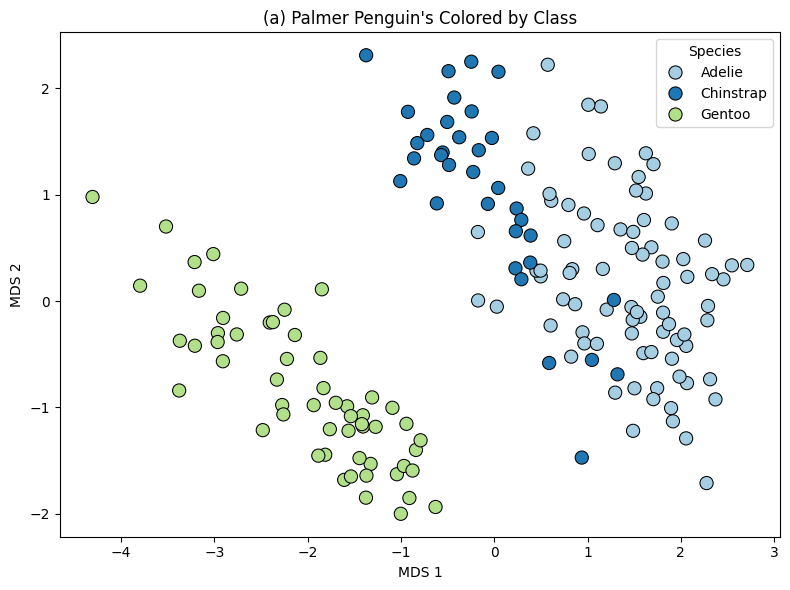

C:\Users\sofia\AppData\Local\Temp\ipykernel_53132\3611067814.py:137: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_knn_zscore['outlier'] = df_knn_zscore.groupby('species', group_keys=False).apply(compute_outliers)


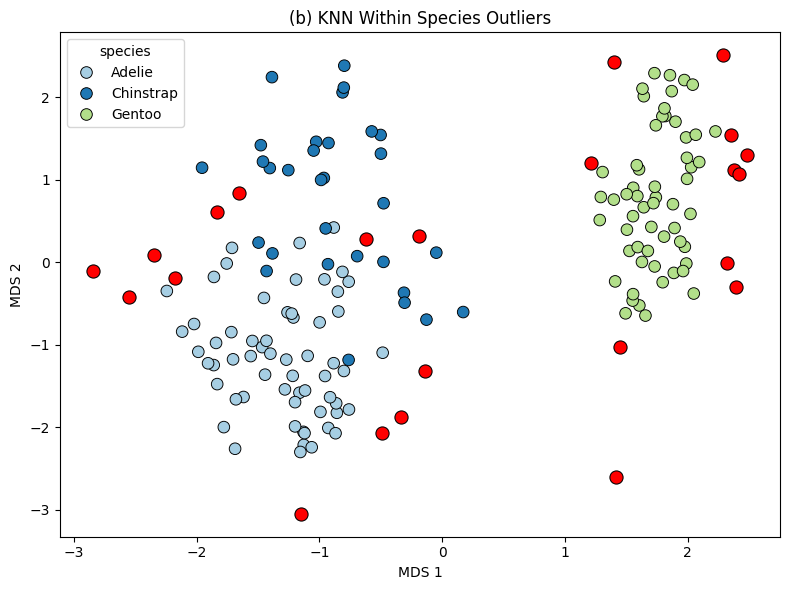

In [260]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import MDS

# --- Assume df, penguin_TRAIN, penguin_TEST, X_Train, Y_Train already defined as you have ---

# Step 1: Fit KNN and calculate distance-based outlier scores on training data
k = 5
knn_manifold = KNeighborsClassifier(n_neighbors=k)
knn_manifold.fit(X_Train, Y_Train)

# Get distances to k nearest neighbors for each training point
distances_manifold, indices_manifold = knn_manifold.kneighbors(X_Train)

# Outlier score: average distance to k nearest neighbors (higher means more outlier-like)
avg_distances_manifold = np.mean(distances_manifold, axis=1)

# Normalize using median and MAD (like PF-GAP)
median_dist_manifold = np.median(avg_distances_manifold)
mad_dist_manifold = np.median(np.abs(avg_distances_manifold - median_dist_manifold))
if mad_dist_manifold == 0:
    mad_dist_manifold = 1e-6

normalized_scores_manifold = np.abs(avg_distances_manifold - median_dist_manifold) / mad_dist_manifold

# Step 2: Create MDS embedding on training data (using Euclidean distances)
embed = MDS(n_components=2, random_state=0)
x_trans = embed.fit_transform(X_Train)
xt = x_trans.transpose()

# Step 3: Create DataFrame for plotting
label_map = {0: "Adelie", 1: "Chinstrap", 2: "Gentoo"}
colorlab = Y_Train
named_labels = colorlab.map(label_map)

outlier_threshold = 3  # same threshold as PF-GAP for consistency
outliers = normalized_scores_manifold > outlier_threshold

df_knn_plot = pd.DataFrame({
    'x': xt[0],
    'y': xt[1],
    'species': named_labels,
    'outlier': outliers
})

# Step 4: Plot KNN outliers - normal points colored by species
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_knn_plot[~df_knn_plot['outlier']],
    x='x', y='y',
    hue='species',
    palette='Paired',
    edgecolor='black',
    s=70
)

# Overlay outliers in red
sns.scatterplot(
    data=df_knn_plot[df_knn_plot['outlier']],
    x='x', y='y',
    color='red',
    marker='o',
    s=90,
    edgecolor='black',
    legend=False
)

plt.title("MDS Embedding of Penguins Dataset KNN")
plt.xlabel("MDS 1")
plt.ylabel("MDS 2")

handles, labels = plt.gca().get_legend_handles_labels()
filtered = [(h, l) for h, l in zip(handles, labels) if l != "True"]
if filtered:
    handles, labels = zip(*filtered)
    plt.legend(handles=handles, labels=labels, title="Species")

plt.tight_layout()
plt.savefig("knn_outlierplot.pdf")
plt.show()

# Step 5: Plot classification correctness colored by species and style by correctness

# Fit KNN classifier and predict test set correctness for plotting style
knn_model = KNeighborsClassifier()
knn_model.fit(penguin_TRAIN.drop(columns="species"), penguin_TRAIN.species)
pred = knn_model.predict(penguin_TEST.drop(columns="species"))
is_correct_test = pred == penguin_TEST.species

# Transform test set for embedding (MDS on test set)
x_trans_test = embed.fit_transform(penguin_TEST.drop(columns="species"))

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=x_trans_test[:, 0],
    y=x_trans_test[:, 1],
    palette="Paired",
    hue=penguin_TEST.species.map(label_map),
    marker='o',
    s=90,
    edgecolor="black"
)

plt.title("(a) Palmer Penguin's Colored by Class")
plt.xlabel("MDS 1")
plt.ylabel("MDS 2")

handles, labels = plt.gca().get_legend_handles_labels()
filtered = [(h, l) for h, l in zip(handles, labels) if l != "True"]
if filtered:
    handles, labels = zip(*filtered)
    plt.legend(handles=handles, labels=labels, title="Species")

plt.tight_layout()
plt.savefig("knn_classplot.pdf")
plt.show()

# Step 6: Species-wise Z-score outlier detection (like your PF-GAP last plot before commented out)

from scipy.stats import zscore

df_knn_zscore = pd.DataFrame({
    'x': xt[0],
    'y': xt[1],
    'species': named_labels
})

def compute_outliers(group, threshold=2):
    z_x = zscore(group['x'])
    z_y = zscore(group['y'])
    combined_z = np.sqrt(z_x**2 + z_y**2)
    return pd.Series(combined_z > threshold, index=group.index)

df_knn_zscore['outlier'] = df_knn_zscore.groupby('species', group_keys=False).apply(compute_outliers)

# Plot inliers
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_knn_zscore[~df_knn_zscore['outlier']],
    x='x',
    y='y',
    hue='species',
    palette='Paired',
    edgecolor='black',
    s=70
)

# Plot outliers in red
sns.scatterplot(
    data=df_knn_zscore[df_knn_zscore['outlier']],
    x='x',
    y='y',
    color='red',
    marker='o',
    s=90,
    edgecolor='black',
    legend=False
)

plt.title("(b) KNN Within Species Outliers")
plt.xlabel("MDS 1")
plt.ylabel("MDS 2")

plt.tight_layout()
plt.savefig("knn_classoutlier.pdf")
plt.show()


In [261]:
# ## KNN Outlier Code
# ## For KNN manifold, we'll use the distance-based outlier detection
#                         ## This is how KNN naturally identifies outliers
# k = 5 
# knn_manifold = KNeighborsClassifier(n_neighbors=k)
# knn_manifold.fit(X_Train, Y_Train)
# ## Get distances to k nearest neighbors for each training point
# distances_manifold, indices_manifold = knn_manifold.kneighbors(X_Train)
# ## Outlier score based on average distance to k nearest neighbors
# ## Higher distances indicate more outlier-like behavior
# avg_distances_manifold = np.mean(distances_manifold, axis=1)
# ## Normalize by the median distance (similar to PFGAP approach)
# median_dist_manifold = np.median(avg_distances_manifold)
# mad_dist_manifold = np.median(np.abs(avg_distances_manifold - median_dist_manifold))
# if mad_dist_manifold == 0:
#     mad_dist_manifold = 1e-6
# normalized_scores_manifold = np.abs(avg_distances_manifold - median_dist_manifold) / mad_dist_manifold

In [262]:
# # COMMENTING OUT BECAUSE SAME GRAPH IS CREATED ABOVE BUT IS MISSING A CLASS
# cmap = plt.cm.Paired
# #plt.figure(figsize = (15,10))
# for i in range(1,3):
#     cmap1 = [i-1 for j in range(eX[i-1].shape[1])]
#     #if y[np.argmax(sizes)] == i:
#      #   cmap1[np.argmax(eval("outs" + str(i)))] = 5
#     #plt.scatter(eX[i-1][0], eX[i-1][1], c=cmap(cmap1), s=Outs[i-1],
#      #           label="Class {:g}".format(i-1))
#     plt.scatter(eX[i-1][0], eX[i-1][1], c=cmap(cmap1),
#                 label="Class {:g}".format(i-1))
    
# plt.legend()
# plt.xlabel('MDS component 1')
# plt.ylabel('MDS component 2')
# plt.title('MDS embedding using PFGAP')
# plt.show()